# Simple Linear Regression: Ordinary Least Squares

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain the **regression model** $Y = \beta_0 + \beta_1 X + \varepsilon$ and the meaning of each term.
2. Derive the **OLS estimators** $\hat\beta_0$ and $\hat\beta_1$ from first principles using calculus.
3. Implement simple linear regression **from scratch** in NumPy.
4. Interpret the **geometric** properties of the regression line (passes through $(\bar x, \bar y)$, slope-correlation relationship).
5. Compute **standard errors**, perform **t-tests** on coefficients, and interpret $R^2$.
6. Use `statsmodels.OLS` for professional regression analysis and read its summary output.
7. Distinguish **confidence intervals** for the mean response from **prediction intervals** for a new observation.

## Prerequisites

- [Module 02](../02_distributions/02_continuous_distributions.ipynb) -- Normal distribution
- [Module 04](../04_estimation/04_confidence_intervals.ipynb) -- Confidence intervals, sampling distributions
- [Module 05](../05_hypothesis_testing/01_hypothesis_framework.ipynb) -- Hypothesis testing, p-values

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0 statsmodels"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The Regression Problem

### Why "regression"?

The term comes from **Sir Francis Galton** (1886), who studied the heights of parents and their adult children. He noticed that very tall parents tended to have children shorter than themselves, and very short parents tended to have children taller than themselves. Heights appeared to *regress toward the mean* of the population. To quantify this phenomenon, Galton drew the line that best summarised the relationship between parent height ($x$) and child height ($y$) -- and **regression analysis** was born.

Today the term "regression" has lost its original meaning. It simply refers to any method for modelling the relationship between a **response variable** $Y$ and one or more **predictor variables** (also called explanatory variables, features, or covariates).

### The question

Given paired observations $(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$:

> **Find the straight line $y = \beta_0 + \beta_1 x$ that best describes how $Y$ depends on $X$.**

"Best" will be made precise in Section 3. For now, let us look at some data to build intuition.

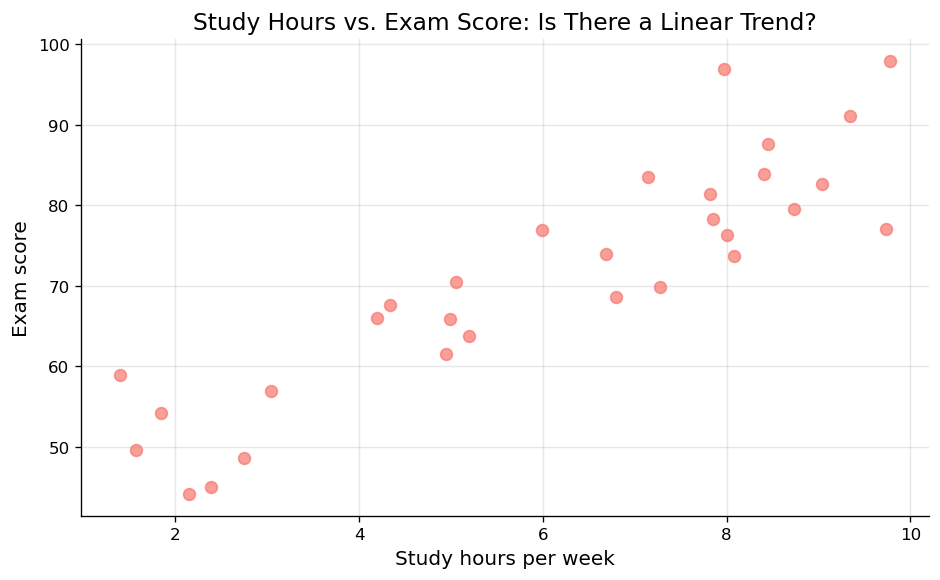

The data were generated with true parameters:
  beta_0 = 40, beta_1 = 5, sigma = 8
We will now derive the method to estimate these from data alone.


In [2]:
# Generate simple example data: study hours vs exam score
n = 30
x = rng.uniform(1, 10, n)
beta_0_true, beta_1_true, sigma_true = 40, 5, 8
y = beta_0_true + beta_1_true * x + rng.normal(0, sigma_true, n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=50, alpha=0.7, zorder=3)
ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")
ax.set_title("Study Hours vs. Exam Score: Is There a Linear Trend?")
plt.tight_layout()
plt.show()

print(f"The data were generated with true parameters:")
print(f"  beta_0 = {beta_0_true}, beta_1 = {beta_1_true}, sigma = {sigma_true}")
print(f"We will now derive the method to estimate these from data alone.")

There is a clear upward trend. But which line through this cloud of points is the *best* one? How do we even define "best"? This is the question that OLS answers.

---

## 2. The Statistical Model

We assume each observation arises from the following **data-generating process**:

$$Y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad \varepsilon_i \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2), \qquad i = 1, \ldots, n$$

Let us unpack every piece:

| Symbol          | Name           | Meaning                                                                                                  |
|-----------------|----------------|----------------------------------------------------------------------------------------------------------|
| $Y_i$           | Response       | The variable we want to predict or explain                                                               |
| $x_i$           | Predictor      | The variable we observe/control (treated as **fixed**, non-random)                                       |
| $\beta_0$       | Intercept      | The expected value of $Y$ when $x = 0$                                                                   |
| $\beta_1$       | Slope          | The expected change in $Y$ per unit increase in $x$                                                      |
| $\varepsilon_i$ | Error          | Random deviation of the $i$-th observation from the line; captures everything the model does not explain |
| $\sigma^2$      | Error variance | How much the observations scatter around the line                                                        |

### What the model says

- **Conditional expectation:** $E[Y_i \mid x_i] = \beta_0 + \beta_1 x_i$. On average, the data follow a straight line.
- **Conditional variance:** $\operatorname{Var}(Y_i \mid x_i) = \sigma^2$. The scatter around the line is the same at every $x$ (**homoscedasticity**).
- **Independence:** The errors $\varepsilon_1, \ldots, \varepsilon_n$ are independent of one another.
- **Normality:** Each error is normally distributed (needed for inference, not for estimation).

### What does "linear" mean?

"Linear" in **linear regression** means *linear in the parameters* $\beta_0$ and $\beta_1$, **not** necessarily linear in $x$. The model

$$Y = \beta_0 + \beta_1 x^2 + \varepsilon$$

is a *linear* regression model because $Y$ is a linear function of $(\beta_0, \beta_1)$, even though the relationship with $x$ is quadratic. Conversely,

$$Y = \beta_0 e^{\beta_1 x} + \varepsilon$$

is a *nonlinear* model because $\beta_1$ appears inside the exponent. This distinction matters because OLS gives us closed-form estimators for linear models, whereas nonlinear models require iterative numerical optimisation.

---

## 3. The Least Squares Criterion

For a candidate line $\hat y_i = b_0 + b_1 x_i$, the **residual** for observation $i$ is the vertical distance between the observed point and the line:

$$e_i = y_i - \hat y_i = y_i - b_0 - b_1 x_i$$

We want to choose $b_0$ and $b_1$ to make the residuals as small as possible. But "small" needs to be defined for the *collection* of all $n$ residuals. The **Residual Sum of Squares** (RSS) squares each residual and adds them up:

$$\operatorname{RSS}(b_0, b_1) = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} (y_i - b_0 - b_1 x_i)^2$$

### Why squared residuals?

There are several possible loss functions. Why choose the sum of *squares* rather than, say, the sum of absolute values $\sum |e_i|$?

1. **Differentiability.** Squared residuals are smooth, so we can use calculus (partial derivatives) to find the minimum analytically. The absolute value $|e|$ has a kink at zero, making the optimisation harder.
2. **Penalises large errors.** Squaring gives disproportionate weight to outliers. A residual of 10 contributes $100$ to RSS, whereas a residual of 1 contributes only $1$. If you want the line to avoid large mistakes, this is desirable.
3. **Connection to maximum likelihood.** Under the normal-error assumption $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, the OLS estimates are also the **maximum likelihood estimates** (Module 04, notebook 03). This gives OLS a deep probabilistic justification.
4. **Mathematical elegance.** The minimiser has a closed-form solution involving only means, variances, and covariances -- the most fundamental summary statistics.

> **Definition (OLS).** The **ordinary least squares** estimators $(\hat\beta_0, \hat\beta_1)$ are the values that minimise $\operatorname{RSS}$:
>
> $$(\hat\beta_0, \hat\beta_1) = \arg\min_{b_0, b_1} \sum_{i=1}^{n} (y_i - b_0 - b_1 x_i)^2$$

---

## 4. Derivation of the OLS Estimators

This is the central derivation of the course. We proceed step by step.

### Step 1: Write down the objective

$$\operatorname{RSS}(b_0, b_1) = \sum_{i=1}^{n} (y_i - b_0 - b_1 x_i)^2$$

We want to find the values of $b_0$ and $b_1$ that minimise this function. Since RSS is a **sum of squares** (a convex quadratic in $b_0$ and $b_1$), any critical point is a global minimum.

### Step 2: Take partial derivatives

**Partial derivative with respect to $b_0$:**

$$\frac{\partial \operatorname{RSS}}{\partial b_0} = \sum_{i=1}^{n} 2(y_i - b_0 - b_1 x_i)(-1) = -2\sum_{i=1}^{n}(y_i - b_0 - b_1 x_i)$$

**Partial derivative with respect to $b_1$:**

$$\frac{\partial \operatorname{RSS}}{\partial b_1} = \sum_{i=1}^{n} 2(y_i - b_0 - b_1 x_i)(-x_i) = -2\sum_{i=1}^{n} x_i(y_i - b_0 - b_1 x_i)$$

### Step 3: Set to zero (the normal equations)

Setting both partial derivatives to zero and dividing by $-2$:

$$\sum_{i=1}^{n}(y_i - \hat\beta_0 - \hat\beta_1 x_i) = 0 \tag{I}$$

$$\sum_{i=1}^{n} x_i(y_i - \hat\beta_0 - \hat\beta_1 x_i) = 0 \tag{II}$$

These are the **normal equations** of least squares.

### Step 4: Solve equation (I) for $\hat\beta_0$

Expand equation (I):

$$\sum_{i=1}^n y_i - n\hat\beta_0 - \hat\beta_1 \sum_{i=1}^n x_i = 0$$

Divide through by $n$:

$$\bar y - \hat\beta_0 - \hat\beta_1 \bar x = 0$$

Therefore:

$$\boxed{\hat\beta_0 = \bar y - \hat\beta_1 \bar x} \tag{III}$$

This immediately tells us that **the regression line passes through the point $(\bar x, \bar y)$**.

### Step 5: Substitute (III) into equation (II) to find $\hat\beta_1$

Substitute $\hat\beta_0 = \bar y - \hat\beta_1 \bar x$ into equation (II):

$$\sum_{i=1}^n x_i \bigl(y_i - (\bar y - \hat\beta_1 \bar x) - \hat\beta_1 x_i\bigr) = 0$$

$$\sum_{i=1}^n x_i \bigl((y_i - \bar y) - \hat\beta_1 (x_i - \bar x)\bigr) = 0$$

Expand:

$$\sum_{i=1}^n x_i(y_i - \bar y) - \hat\beta_1 \sum_{i=1}^n x_i(x_i - \bar x) = 0$$

Now we use a standard identity. For any variable $a$ and constant $c$:

$$\sum_{i=1}^n a_i(b_i - \bar b) = \sum_{i=1}^n (a_i - \bar a)(b_i - \bar b)$$

because $\sum(b_i - \bar b) = 0$, so the $\bar a$ term vanishes. Applying this:

$$\sum_{i=1}^n (x_i - \bar x)(y_i - \bar y) - \hat\beta_1 \sum_{i=1}^n (x_i - \bar x)^2 = 0$$

Defining the fundamental quantities:

$$S_{xy} = \sum_{i=1}^n (x_i - \bar x)(y_i - \bar y), \qquad S_{xx} = \sum_{i=1}^n (x_i - \bar x)^2$$

we obtain:

$$\boxed{\hat\beta_1 = \frac{S_{xy}}{S_{xx}}} \tag{IV}$$

### Summary of the OLS estimators

$$\hat\beta_1 = \frac{\sum_{i=1}^n (x_i - \bar x)(y_i - \bar y)}{\sum_{i=1}^n (x_i - \bar x)^2} = \frac{S_{xy}}{S_{xx}}$$

$$\hat\beta_0 = \bar y - \hat\beta_1 \bar x$$

These are **closed-form expressions** -- no iteration required. They depend only on the sample means $\bar x, \bar y$, the sample covariance (via $S_{xy}$), and the sample variance of $x$ (via $S_{xx}$).

---

## 5. From-Scratch Implementation

Let us now implement OLS in plain NumPy, directly from the formulas we just derived.

In [ ]:
def ols_simple(x, y):
    """Ordinary least squares for simple linear regression.

    Parameters
    ----------
    x : array-like, shape (n,)
        Predictor values.
    y : array-like, shape (n,)
        Response values.

    Returns
    -------
    beta_0 : float
        Estimated intercept.
    beta_1 : float
        Estimated slope.
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n = len(x)
    assert n == len(y), "x and y must have the same length"
    assert n >= 2, "need at least 2 observations"

    x_bar = x.mean()
    y_bar = y.mean()

    S_xy = np.sum((x - x_bar) * (y - y_bar))
    S_xx = np.sum((x - x_bar) ** 2)

    beta_1 = S_xy / S_xx
    beta_0 = y_bar - beta_1 * x_bar

    return beta_0, beta_1


# Test on our simulated data
b0_hat, b1_hat = ols_simple(x, y)

print("OLS estimates (from scratch):")
print(f"  beta_0_hat = {b0_hat:.4f}   (true: {beta_0_true})")
print(f"  beta_1_hat = {b1_hat:.4f}   (true: {beta_1_true})")
print(f"\nThe estimates are close to the true values, but not exact")
print(f"because of the random noise (sigma = {sigma_true}).")

OLS estimates (from scratch):
  beta_0_hat = 41.7001   (true: 40)
  beta_1_hat = 4.8690   (true: 5)

The estimates are close to the true values, but not exact
because of the random noise (sigma = 8).


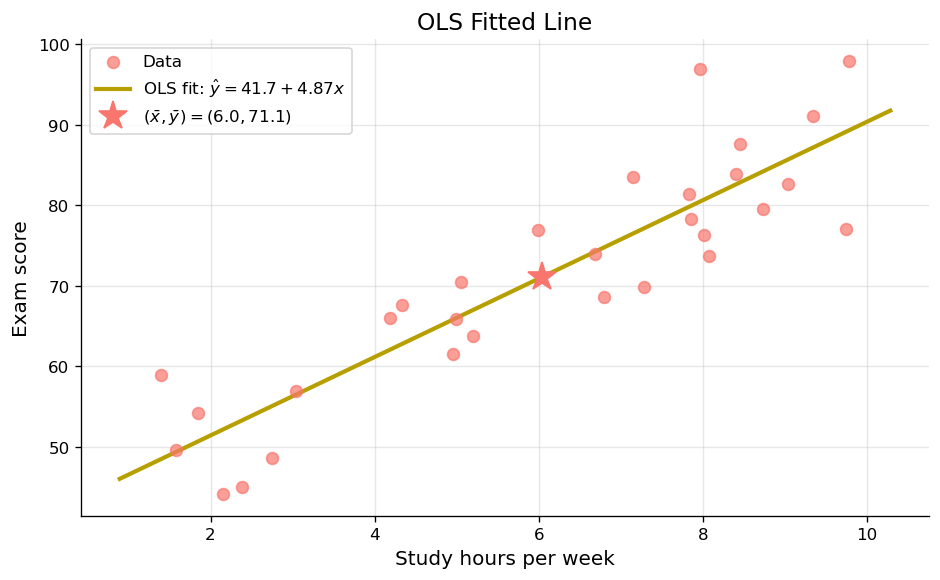

In [ ]:
# Visualise the fitted line
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=50, alpha=0.7, zorder=3, label="Data")

x_line = np.linspace(x.min() - 0.5, x.max() + 0.5, 200)
y_line = b0_hat + b1_hat * x_line
ax.plot(
    x_line,
    y_line,
    color="#B79F00",
    linewidth=2.5,
    label=f"OLS fit: $\\hat y = {b0_hat:.1f} + {b1_hat:.2f}x$",
)

# Mark (x_bar, y_bar)
ax.plot(
    x.mean(),
    y.mean(),
    "*",
    color="#F8766D",
    markersize=18,
    zorder=5,
    label=f"$(\\bar x, \\bar y) = ({x.mean():.1f}, {y.mean():.1f})$",
)

ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")
ax.set_title("OLS Fitted Line")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The fitted line passes through the centroid $(\bar x, \bar y)$, exactly as equation (III) guarantees.

---

## 6. Geometric Interpretation

The OLS estimators have elegant geometric properties that connect regression to correlation.

### The regression line passes through $(\bar x, \bar y)$

We already proved this: $\hat\beta_0 = \bar y - \hat\beta_1 \bar x$ implies $\hat y|_{x = \bar x} = \bar y$. The centroid of the data always lies on the regression line.

### Slope, correlation, and standard deviations

The slope can be written in a revealing form. Recall:

$$\hat\beta_1 = \frac{S_{xy}}{S_{xx}}$$

The sample correlation coefficient is:

$$r = \frac{S_{xy}}{\sqrt{S_{xx} \cdot S_{yy}}}$$

where $S_{yy} = \sum(y_i - \bar y)^2$. The sample standard deviations satisfy $s_x = \sqrt{S_{xx}/(n-1)}$ and $s_y = \sqrt{S_{yy}/(n-1)}$, so $S_{xy}/S_{xx} = r \cdot \sqrt{S_{yy}/S_{xx}} = r \cdot s_y / s_x$. Therefore:

$$\boxed{\hat\beta_1 = r \cdot \frac{s_y}{s_x}}$$

This is a beautiful identity. It says:

- The **sign** of the slope equals the sign of the correlation.
- The **magnitude** of the slope is the correlation *scaled* by the ratio of the standard deviations.
- If $x$ and $y$ have the same units and spread ($s_x = s_y$), then $\hat\beta_1 = r$ exactly.
- A correlation of $r = 1$ means the points fall perfectly on a line with slope $s_y / s_x$.

### Galton's regression to the mean

If we standardise both variables (subtract the mean, divide by the SD), the slope becomes exactly $r$. Since $|r| \leq 1$, a one-SD increase in $x$ predicts *less than* a one-SD increase in $y$. This is "regression to the mean" -- extreme $x$ values predict less extreme $y$ values.

In [ ]:
# Verify the slope-correlation identity
r = np.corrcoef(x, y)[0, 1]
s_x = x.std(ddof=1)
s_y = y.std(ddof=1)

slope_from_formula = b1_hat
slope_from_r = r * s_y / s_x

print(f"Correlation r = {r:.4f}")
print(f"s_y / s_x = {s_y:.4f} / {s_x:.4f} = {s_y / s_x:.4f}")
print(f"")
print(f"beta_1 from OLS formula:       {slope_from_formula:.6f}")
print(f"beta_1 from r * s_y / s_x:     {slope_from_r:.6f}")
print(f"Difference:                     {abs(slope_from_formula - slope_from_r):.2e}")
print(f"")
print(f"They agree to machine precision, as the algebra guarantees.")

Correlation r = 0.8959
s_y / s_x = 14.4727 / 2.6631 = 5.4345

beta_1 from OLS formula:       4.869021
beta_1 from r * s_y / s_x:     4.869021
Difference:                     8.88e-16

They agree to machine precision, as the algebra guarantees.


---

## 7. Residuals

The **residuals** are the vertical distances between the observed values and the fitted line:

$$e_i = y_i - \hat y_i = y_i - \hat\beta_0 - \hat\beta_1 x_i$$

Residuals are our best approximation to the unobservable errors $\varepsilon_i$. They are the raw material for **diagnostics** -- checking whether the model assumptions are reasonable.

### Key properties of OLS residuals

**Property 1: The residuals sum to zero.**

This follows directly from normal equation (I): $\sum(y_i - \hat\beta_0 - \hat\beta_1 x_i) = \sum e_i = 0$.

**Property 2: The residuals are uncorrelated with $x$.**

Normal equation (II) gives $\sum x_i e_i = 0$. Combined with $\sum e_i = 0$, this implies $\sum (x_i - \bar x)(e_i - \bar e) = \sum (x_i - \bar x) e_i = 0$. The sample correlation between $x$ and $e$ is zero.

**Property 3: The residuals are uncorrelated with the fitted values $\hat y$.**

Since $\hat y_i = \hat\beta_0 + \hat\beta_1 x_i$ is a linear function of $x_i$, this follows from Property 2.

These properties are not assumptions -- they are **algebraic consequences** of the OLS fitting procedure. They hold for any dataset, regardless of whether the true model is linear.

Residual properties (verification):
  Sum of residuals:                -4.26e-13  (should be ~0)
  Correlation of e with x:         -1.01e-16  (should be ~0)
  Correlation of e with y_hat:     -1.55e-16  (should be ~0)


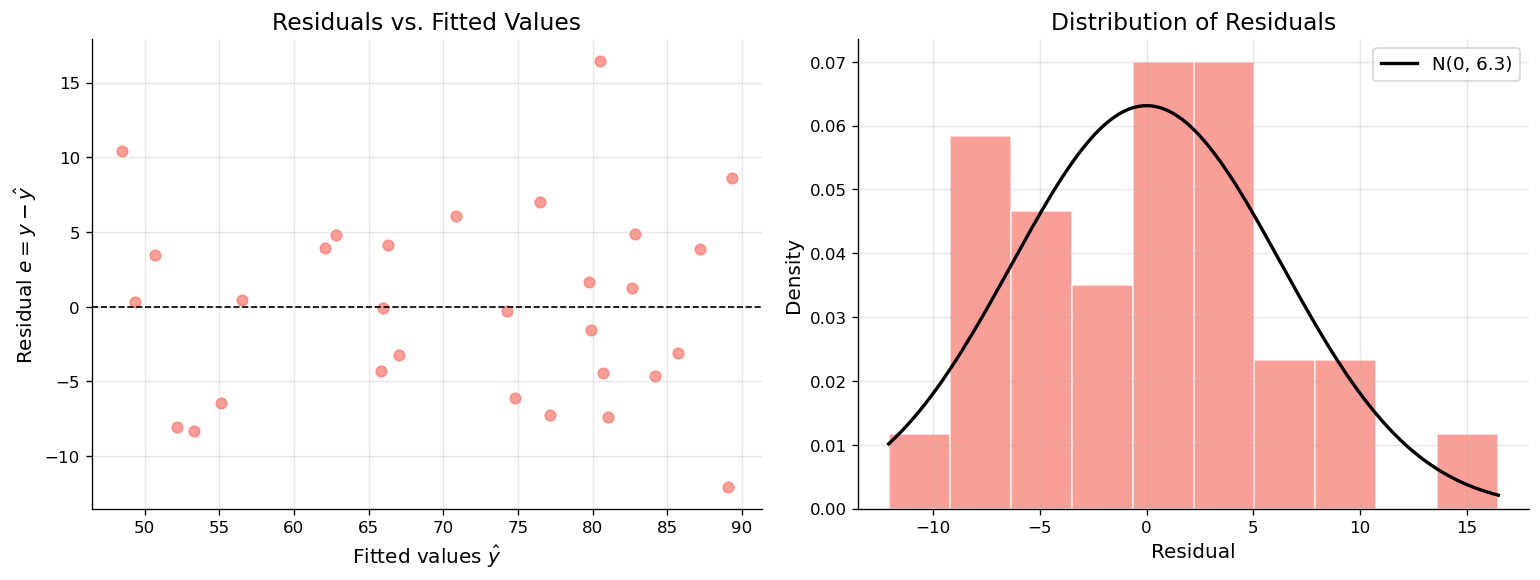


The residuals vs. fitted plot looks like a random scatter around zero
with no obvious pattern -- this is what we want to see.


In [ ]:
# Compute and examine residuals
y_hat = b0_hat + b1_hat * x
residuals = y - y_hat

print("Residual properties (verification):")
print(f"  Sum of residuals:                {residuals.sum():.2e}  (should be ~0)")
print(
    f"  Correlation of e with x:         {np.corrcoef(x, residuals)[0, 1]:.2e}  (should be ~0)"
)
print(
    f"  Correlation of e with y_hat:     {np.corrcoef(y_hat, residuals)[0, 1]:.2e}  (should be ~0)"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs fitted
axes[0].scatter(y_hat, residuals, s=40, alpha=0.7)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Fitted values $\\hat y$")
axes[0].set_ylabel("Residual $e = y - \\hat y$")
axes[0].set_title("Residuals vs. Fitted Values")

# Histogram of residuals
axes[1].hist(residuals, bins=10, density=True, alpha=0.7, edgecolor="white")
z_grid = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(
    z_grid,
    stats.norm.pdf(z_grid, 0, residuals.std()),
    color="black",
    linewidth=2,
    label=f"N(0, {residuals.std():.1f})",
)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of Residuals")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nThe residuals vs. fitted plot looks like a random scatter around zero")
print(f"with no obvious pattern -- this is what we want to see.")

**Reading the residuals-vs-fitted plot:** If the model is correctly specified, this plot should show a random cloud of points centred at zero with constant spread. Patterns such as a funnel shape (heteroscedasticity), a curve (nonlinearity), or clusters indicate model violations. We will study residual diagnostics systematically in a later notebook.

---

## 8. Manim Animation: Visualising OLS

The following animation shows what OLS is doing geometrically. Data points appear, then a line sweeps through different positions. Vertical lines from each point to the line represent the residuals. As the line converges to the OLS solution, the total area of the squared residuals shrinks to its minimum.

In [ ]:
from manim import *

cfg.apply_manim_config()
from amstats.manim_utils import C

Manim Community v0.18.1

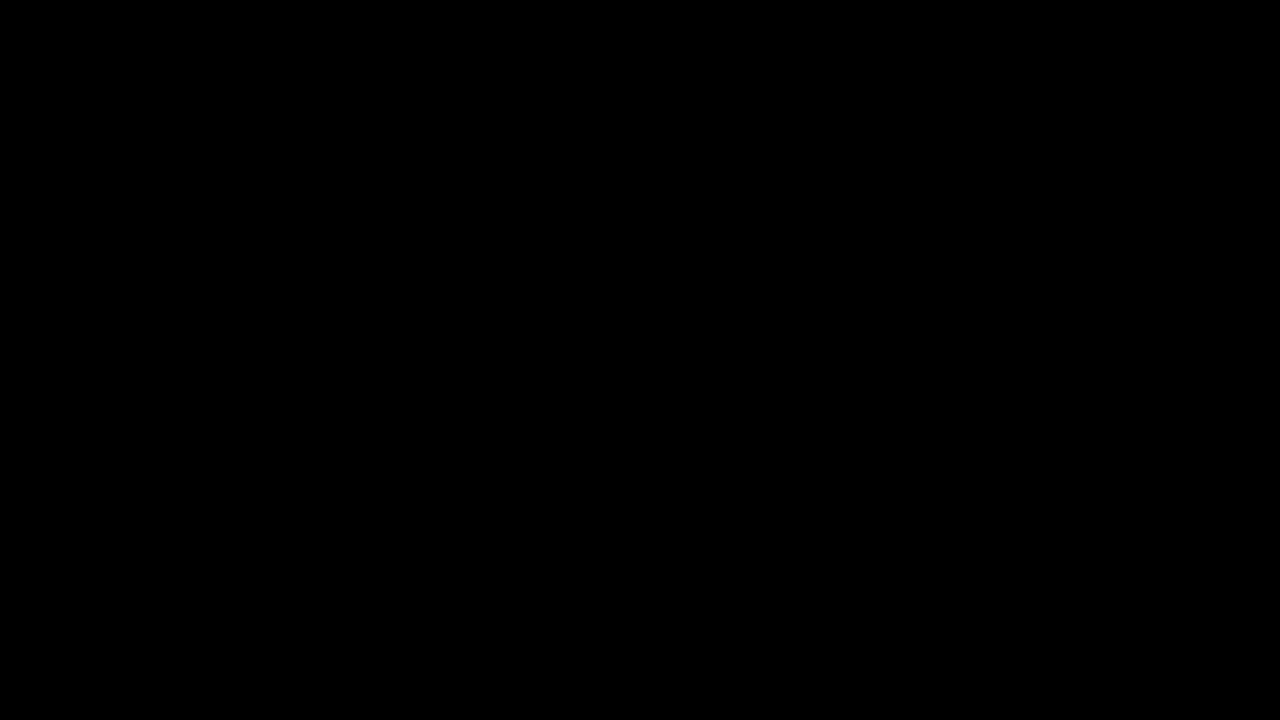

In [ ]:
%%manim -qm -v WARNING OLSFitting


class OLSFitting(Scene):
    def construct(self):
        # --- Data (small set for clarity) ---
        np.random.seed(7)
        n_pts = 12
        xs = np.linspace(1, 9, n_pts) + np.random.normal(0, 0.3, n_pts)
        ys = 2 + 1.5 * xs + np.random.normal(0, 1.5, n_pts)

        # OLS solution
        x_bar, y_bar = xs.mean(), ys.mean()
        S_xy = np.sum((xs - x_bar) * (ys - y_bar))
        S_xx = np.sum((xs - x_bar) ** 2)
        b1_ols = S_xy / S_xx
        b0_ols = y_bar - b1_ols * x_bar

        # --- Axes ---
        axes = Axes(
            x_range=[0, 11, 2],
            y_range=[0, 20, 5],
            x_length=9,
            y_length=5.5,
            axis_config={"include_numbers": True, "font_size": 22},
        ).shift(DOWN * 0.3)
        x_label = axes.get_x_axis_label("x", direction=RIGHT)
        y_label = axes.get_y_axis_label("y", direction=UP)

        self.play(Create(axes), Write(x_label), Write(y_label), run_time=1)

        # --- Plot data points ---
        dots = VGroup(
            *[
                Dot(axes.c2p(xi, yi), radius=0.07, color=C.PERIWINKLE)
                for xi, yi in zip(xs, ys)
            ]
        )
        self.play(
            LaggedStart(*[FadeIn(d, scale=0.5) for d in dots], lag_ratio=0.08),
            run_time=1.5,
        )
        self.wait(0.5)

        # --- Animate line sweeping toward OLS solution ---
        # Start with a bad guess, animate toward OLS
        slopes = np.linspace(0.3, b1_ols, 30)
        intercepts = [y_bar - s * x_bar for s in slopes]  # always through centroid

        def make_line(b0, b1):
            x0, x1 = 0.5, 10.5
            return Line(
                axes.c2p(x0, b0 + b1 * x0),
                axes.c2p(x1, b0 + b1 * x1),
                color=C.GOLD,
                stroke_width=3,
            )

        def make_residual_lines(b0, b1):
            lines = VGroup()
            for xi, yi in zip(xs, ys):
                y_pred = b0 + b1 * xi
                line = Line(
                    axes.c2p(xi, yi),
                    axes.c2p(xi, y_pred),
                    color=C.SALMON,
                    stroke_width=2,
                    stroke_opacity=0.7,
                )
                lines.add(line)
            return lines

        def compute_rss(b0, b1):
            return np.sum((ys - b0 - b1 * xs) ** 2)

        # Initial state
        current_line = make_line(intercepts[0], slopes[0])
        current_resids = make_residual_lines(intercepts[0], slopes[0])
        rss_val = compute_rss(intercepts[0], slopes[0])

        rss_label = Text(
            f"RSS = {rss_val:.0f}", font_size=28, color=C.SALMON
        ).to_corner(UR, buff=0.5)

        self.play(
            Create(current_line),
            Create(current_resids),
            FadeIn(rss_label),
            run_time=0.8,
        )
        self.wait(0.3)

        # Animate sweep — sample ~10 frames
        frame_indices = np.linspace(1, len(slopes) - 1, 12, dtype=int)
        for idx in frame_indices:
            new_line = make_line(intercepts[idx], slopes[idx])
            new_resids = make_residual_lines(intercepts[idx], slopes[idx])
            rss_val = compute_rss(intercepts[idx], slopes[idx])
            new_label = Text(
                f"RSS = {rss_val:.0f}", font_size=28, color=C.SALMON
            ).to_corner(UR, buff=0.5)

            self.play(
                Transform(current_line, new_line),
                Transform(current_resids, new_resids),
                Transform(rss_label, new_label),
                run_time=0.3,
            )

        # Final: highlight OLS solution
        ols_label = Text(
            "OLS solution (minimum RSS)", font_size=24, color=C.GOLD
        ).next_to(rss_label, DOWN, buff=0.3)
        self.play(FadeIn(ols_label), run_time=0.5)
        self.wait(2)

The animation shows the line rotating through $(\bar x, \bar y)$ as the slope increases from a bad initial guess toward the OLS solution. The vertical residual lines (salmon) shrink as the line approaches the optimal fit, and the RSS counter decreases. At the OLS solution, the sum of squared vertical distances is at its minimum -- no other straight line through this data achieves a smaller RSS.

---

## 9. Inference on Coefficients

So far we have *estimated* $\hat\beta_0$ and $\hat\beta_1$. But estimates without uncertainty quantification are incomplete. We need **standard errors**, **confidence intervals**, and **hypothesis tests**.

### Estimating $\sigma^2$

The error variance $\sigma^2$ is unknown and must be estimated from the residuals. The unbiased estimator is:

$$\hat\sigma^2 = s^2 = \frac{\operatorname{RSS}}{n - 2} = \frac{\sum_{i=1}^n e_i^2}{n - 2}$$

We divide by $n - 2$ (not $n$) because we estimated 2 parameters ($\beta_0, \beta_1$), losing 2 degrees of freedom.

### Standard errors of the OLS estimators

Under the model assumptions, the OLS estimators are **normally distributed** (since they are linear functions of the normal $Y_i$):

$$\hat\beta_1 \sim \mathcal{N}\!\left(\beta_1, \; \frac{\sigma^2}{S_{xx}}\right), \qquad \hat\beta_0 \sim \mathcal{N}\!\left(\beta_0, \; \sigma^2\!\left(\frac{1}{n} + \frac{\bar x^2}{S_{xx}}\right)\right)$$

Replacing $\sigma^2$ with $\hat\sigma^2$, the **standard errors** are:

$$\operatorname{SE}(\hat\beta_1) = \frac{\hat\sigma}{\sqrt{S_{xx}}}, \qquad \operatorname{SE}(\hat\beta_0) = \hat\sigma \sqrt{\frac{1}{n} + \frac{\bar x^2}{S_{xx}}}$$

### T-test for the slope

The most common hypothesis test in regression is:

$$H_0: \beta_1 = 0 \qquad \text{vs.} \qquad H_1: \beta_1 \neq 0$$

Under $H_0$, $X$ has no linear effect on $Y$. The test statistic is:

$$t = \frac{\hat\beta_1}{\operatorname{SE}(\hat\beta_1)} \sim t_{n-2}$$

We reject $H_0$ if $|t|$ is large (compared to the $t_{n-2}$ distribution).

### Coefficient of determination: $R^2$

How much of the variation in $Y$ does the model explain? We decompose the **total variability**:

$$\underbrace{\sum(y_i - \bar y)^2}_{\text{TSS (total)}} = \underbrace{\sum(\hat y_i - \bar y)^2}_{\text{ESS (explained)}} + \underbrace{\sum(y_i - \hat y_i)^2}_{\text{RSS (residual)}}$$

$$R^2 = 1 - \frac{\operatorname{RSS}}{\operatorname{TSS}} = \frac{\operatorname{ESS}}{\operatorname{TSS}}$$

$R^2 \in [0, 1]$ measures the proportion of variance explained by the model. In simple linear regression, $R^2 = r^2$ (the square of the correlation coefficient).

In [ ]:
# Full from-scratch inference
def ols_simple_full(x, y):
    """OLS for simple linear regression with full inference."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n = len(x)
    x_bar, y_bar = x.mean(), y.mean()

    S_xx = np.sum((x - x_bar) ** 2)
    S_xy = np.sum((x - x_bar) * (y - y_bar))
    S_yy = np.sum((y - y_bar) ** 2)

    # Estimates
    beta_1 = S_xy / S_xx
    beta_0 = y_bar - beta_1 * x_bar
    y_hat = beta_0 + beta_1 * x
    residuals = y - y_hat

    # Sums of squares
    RSS = np.sum(residuals**2)
    TSS = S_yy
    ESS = TSS - RSS

    # Estimated error variance
    sigma2_hat = RSS / (n - 2)
    sigma_hat = np.sqrt(sigma2_hat)

    # Standard errors
    se_beta_1 = sigma_hat / np.sqrt(S_xx)
    se_beta_0 = sigma_hat * np.sqrt(1 / n + x_bar**2 / S_xx)

    # t-statistics
    t_beta_1 = beta_1 / se_beta_1
    t_beta_0 = beta_0 / se_beta_0

    # p-values (two-sided)
    p_beta_1 = 2 * stats.t.sf(abs(t_beta_1), n - 2)
    p_beta_0 = 2 * stats.t.sf(abs(t_beta_0), n - 2)

    # R-squared
    R2 = 1 - RSS / TSS

    return {
        "beta_0": beta_0,
        "beta_1": beta_1,
        "se_beta_0": se_beta_0,
        "se_beta_1": se_beta_1,
        "t_beta_0": t_beta_0,
        "t_beta_1": t_beta_1,
        "p_beta_0": p_beta_0,
        "p_beta_1": p_beta_1,
        "sigma_hat": sigma_hat,
        "R2": R2,
        "RSS": RSS,
        "TSS": TSS,
        "ESS": ESS,
        "residuals": residuals,
        "y_hat": y_hat,
        "n": n,
        "df": n - 2,
    }


results = ols_simple_full(x, y)

print("=" * 60)
print("  Simple Linear Regression Results (from scratch)")
print("=" * 60)
print(f"  n = {results['n']},  df = {results['df']}")
print(f"")
print(f"  {'':12s} {'Estimate':>10s} {'Std Err':>10s} {'t-stat':>10s} {'p-value':>10s}")
print(f"  {'-' * 52}")
print(
    f"  {'Intercept':12s} {results['beta_0']:10.4f} {results['se_beta_0']:10.4f}"
    f" {results['t_beta_0']:10.3f} {results['p_beta_0']:10.4f}"
)
print(
    f"  {'Slope':12s} {results['beta_1']:10.4f} {results['se_beta_1']:10.4f}"
    f" {results['t_beta_1']:10.3f} {results['p_beta_1']:10.6f}"
)
print(f"")
print(f"  sigma_hat = {results['sigma_hat']:.4f}")
print(f"  R-squared = {results['R2']:.4f}")
print(
    f"  RSS = {results['RSS']:.2f},  ESS = {results['ESS']:.2f},  TSS = {results['TSS']:.2f}"
)
print(f"=" * 60)

  Simple Linear Regression Results (from scratch)
  n = 30,  df = 28

                 Estimate    Std Err     t-stat    p-value
  ----------------------------------------------------
  Intercept       41.7001     2.9998     13.901     0.0000
  Slope            4.8690     0.4562     10.674   0.000000

  sigma_hat = 6.5421
  R-squared = 0.8027
  RSS = 1198.36,  ESS = 4875.97,  TSS = 6074.33


The slope is highly significant ($p \ll 0.05$), so we reject $H_0: \beta_1 = 0$ -- there is strong evidence of a linear relationship between study hours and exam score. The $R^2$ value tells us what fraction of the variability in exam scores is explained by study hours.

---

## 10. Professional Tool: `statsmodels.OLS`

In practice, you would use a well-tested library. `statsmodels` provides a comprehensive regression framework with detailed output.

In [10]:
import statsmodels.api as sm

# statsmodels requires us to add a constant (intercept) column manually
X_sm = sm.add_constant(x)  # adds a column of 1s
model = sm.OLS(y, X_sm)
fit = model.fit()

print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     113.9
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           2.24e-11
Time:                        07:22:06   Log-Likelihood:                -97.881
No. Observations:                  30   AIC:                             199.8
Df Residuals:                      28   BIC:                             202.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.7001      3.000     13.901      0.0

### Reading the `statsmodels` summary

The output is dense. Here is what every entry means:

**Top panel:**
- **R-squared** -- Proportion of variance explained (same as our $R^2$).
- **Adj. R-squared** -- Adjusted for the number of predictors; penalises adding useless variables. In simple regression, it is close to $R^2$.
- **F-statistic** -- Tests whether *any* predictor is significant. In simple regression, the F-statistic equals $t^2$ for the slope.
- **Prob (F-statistic)** -- p-value for the F-test.
- **AIC / BIC** -- Information criteria for model comparison (lower is better).

**Coefficient table:**
- **coef** -- The estimated $\hat\beta$.
- **std err** -- Standard error of the estimate.
- **t** -- t-statistic = coef / std err.
- **P>|t|** -- Two-sided p-value for $H_0: \beta = 0$.
- **[0.025, 0.975]** -- 95% confidence interval for the coefficient.

**Bottom panel:**
- **Omnibus / Prob(Omnibus)** -- Test for normality of residuals.
- **Durbin-Watson** -- Test for autocorrelation in residuals (values near 2 are good).
- **Jarque-Bera** -- Another normality test.
- **Cond. No.** -- Condition number; large values indicate multicollinearity (more relevant for multiple regression).

In [ ]:
# Verify our from-scratch results match statsmodels
print("Verification: from-scratch vs. statsmodels")
print(f"")
print(f"{'':20s} {'From scratch':>14s} {'statsmodels':>14s}")
print(f"{'-' * 48}")
print(f"{'beta_0':20s} {results['beta_0']:14.6f} {fit.params[0]:14.6f}")
print(f"{'beta_1':20s} {results['beta_1']:14.6f} {fit.params[1]:14.6f}")
print(f"{'SE(beta_0)':20s} {results['se_beta_0']:14.6f} {fit.bse[0]:14.6f}")
print(f"{'SE(beta_1)':20s} {results['se_beta_1']:14.6f} {fit.bse[1]:14.6f}")
print(f"{'t(beta_1)':20s} {results['t_beta_1']:14.6f} {fit.tvalues[1]:14.6f}")
print(f"{'p(beta_1)':20s} {results['p_beta_1']:14.8f} {fit.pvalues[1]:14.8f}")
print(f"{'R-squared':20s} {results['R2']:14.6f} {fit.rsquared:14.6f}")
print(f"{'sigma_hat':20s} {results['sigma_hat']:14.6f} {np.sqrt(fit.mse_resid):14.6f}")
print(f"")
print(f"All values match -- our derivation and implementation are correct.")

Verification: from-scratch vs. statsmodels

                       From scratch    statsmodels
------------------------------------------------
beta_0                    41.700150      41.700150
beta_1                     4.869021       4.869021
SE(beta_0)                 2.999766       2.999766
SE(beta_1)                 0.456169       0.456169
t(beta_1)                 10.673732      10.673732
p(beta_1)                0.00000000     0.00000000
R-squared                  0.802718       0.802718
sigma_hat                  6.542058       6.542058

All values match -- our derivation and implementation are correct.


---

## 11. Prediction and Intervals

Once we have a fitted model, we can **predict** the response at a new value $x^*$:

$$\hat y^* = \hat\beta_0 + \hat\beta_1 x^*$$

But there are two different questions we might ask, and they have different uncertainties:

### Confidence interval for the mean response $E[Y \mid x^*]$

"What is the *average* exam score for students who study $x^*$ hours?" The uncertainty comes only from estimating $\beta_0$ and $\beta_1$:

$$\operatorname{Var}(\hat y^*) = \sigma^2 \left(\frac{1}{n} + \frac{(x^* - \bar x)^2}{S_{xx}}\right)$$

$$\text{CI for } E[Y \mid x^*]: \quad \hat y^* \pm t_{n-2, \alpha/2} \cdot \hat\sigma \sqrt{\frac{1}{n} + \frac{(x^* - \bar x)^2}{S_{xx}}}$$

### Prediction interval for a new observation $Y^*$

"What score will a *specific* new student who studies $x^*$ hours get?" Now there is additional uncertainty from the random error $\varepsilon^*$:

$$\operatorname{Var}(Y^* - \hat y^*) = \sigma^2 \left(1 + \frac{1}{n} + \frac{(x^* - \bar x)^2}{S_{xx}}\right)$$

$$\text{PI for } Y^*: \quad \hat y^* \pm t_{n-2, \alpha/2} \cdot \hat\sigma \sqrt{1 + \frac{1}{n} + \frac{(x^* - \bar x)^2}{S_{xx}}}$$

The prediction interval is always **wider** than the confidence interval because it accounts for individual variation ($\varepsilon^*$) on top of estimation uncertainty. Note that both intervals are **narrowest at $x = \bar x$** and widen as $x^*$ moves away from the centre of the data -- predictions are most precise where we have the most information.

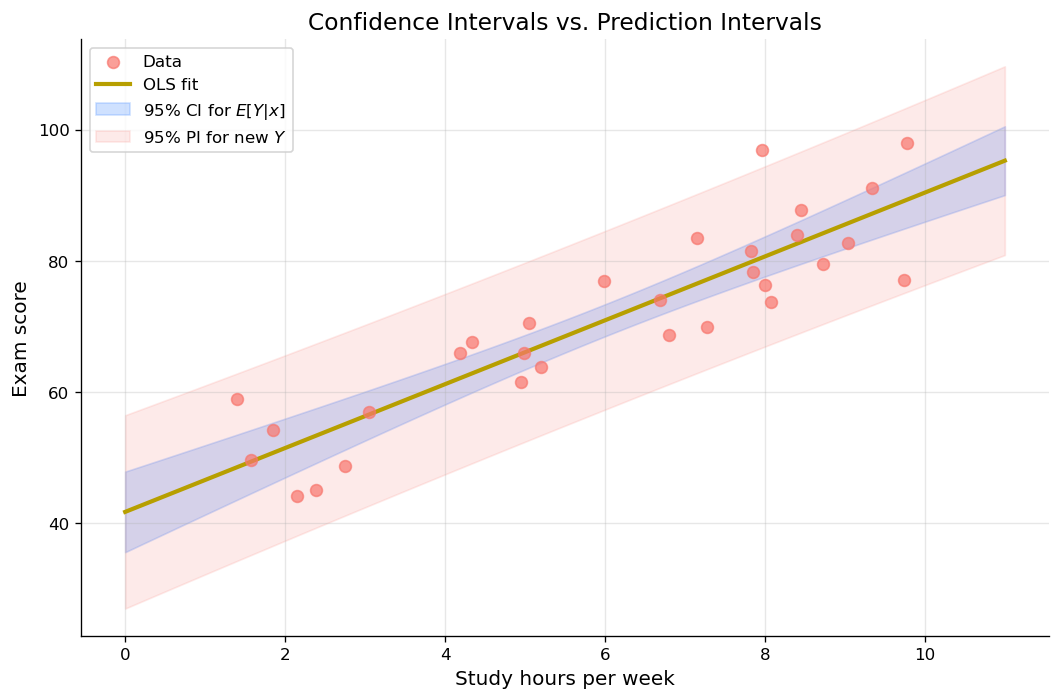

Key observations:
  - The prediction interval (salmon) is always wider than the confidence interval (blue).
  - Both intervals are narrowest near x_bar and widen at the edges.
  - About 95% of data points should fall within the prediction interval.
  - Actual coverage: 29/30 = 97% of points inside the PI.


In [ ]:
# Compute and plot confidence and prediction intervals
def prediction_intervals(x, y, x_new, alpha=0.05):
    """Compute CI for E[Y|x] and PI for Y at new x values."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    x_new = np.asarray(x_new, float)
    n = len(x)
    x_bar = x.mean()
    S_xx = np.sum((x - x_bar) ** 2)

    b1 = np.sum((x - x_bar) * (y - y.mean())) / S_xx
    b0 = y.mean() - b1 * x_bar

    y_hat = b0 + b1 * x
    resid = y - y_hat
    sigma_hat = np.sqrt(np.sum(resid**2) / (n - 2))

    y_new = b0 + b1 * x_new
    t_crit = stats.t.ppf(1 - alpha / 2, n - 2)

    # Variance for mean response
    var_mean = sigma_hat**2 * (1 / n + (x_new - x_bar) ** 2 / S_xx)
    ci_half = t_crit * np.sqrt(var_mean)

    # Variance for individual prediction
    var_pred = sigma_hat**2 * (1 + 1 / n + (x_new - x_bar) ** 2 / S_xx)
    pi_half = t_crit * np.sqrt(var_pred)

    return y_new, ci_half, pi_half


x_grid = np.linspace(0, 11, 200)
y_pred, ci_hw, pi_hw = prediction_intervals(x, y, x_grid)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, s=50, alpha=0.7, zorder=5, label="Data")
ax.plot(x_grid, y_pred, color="#B79F00", linewidth=2.5, label="OLS fit")

# Confidence interval for the mean
ax.fill_between(
    x_grid,
    y_pred - ci_hw,
    y_pred + ci_hw,
    color="#619CFF",
    alpha=0.3,
    label="95% CI for $E[Y|x]$",
)

# Prediction interval
ax.fill_between(
    x_grid,
    y_pred - pi_hw,
    y_pred + pi_hw,
    color="#F8766D",
    alpha=0.15,
    label="95% PI for new $Y$",
)

ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")
ax.set_title("Confidence Intervals vs. Prediction Intervals")
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

print("Key observations:")
print(
    "  - The prediction interval (salmon) is always wider than the confidence interval (blue)."
)
print("  - Both intervals are narrowest near x_bar and widen at the edges.")
print("  - About 95% of data points should fall within the prediction interval.")
in_pi = np.sum(
    (y >= np.interp(x, x_grid, y_pred - pi_hw))
    & (y <= np.interp(x, x_grid, y_pred + pi_hw))
)
print(
    f"  - Actual coverage: {in_pi}/{len(y)} = {in_pi / len(y):.0%} of points inside the PI."
)

In [ ]:
# Specific prediction example
x_star = 7.0
y_star, ci_star, pi_star = prediction_intervals(x, y, np.array([x_star]))

print(f"Prediction at x* = {x_star} hours:")
print(f"  Point estimate: y_hat = {y_star[0]:.2f}")
print(
    f"  95% CI for E[Y|x={x_star}]:  [{y_star[0] - ci_star[0]:.2f}, {y_star[0] + ci_star[0]:.2f}]"
)
print(
    f"  95% PI for a new student:     [{y_star[0] - pi_star[0]:.2f}, {y_star[0] + pi_star[0]:.2f}]"
)
print(f"")
print(f"The CI tells us the average score for all students studying 7h is")
print(
    f"between {y_star[0] - ci_star[0]:.1f} and {y_star[0] + ci_star[0]:.1f} (with 95% confidence)."
)
print(f"")
print(f"The PI tells us that a specific new student studying 7h will score")
print(
    f"between {y_star[0] - pi_star[0]:.1f} and {y_star[0] + pi_star[0]:.1f} (with 95% confidence)."
)
print(f"The PI is wider because individual students vary around the average.")

Prediction at x* = 7.0 hours:
  Point estimate: y_hat = 75.78
  95% CI for E[Y|x=7.0]:  [73.17, 78.39]
  95% PI for a new student:     [62.13, 89.44]

The CI tells us the average score for all students studying 7h is
between 73.2 and 78.4 (with 95% confidence).

The PI tells us that a specific new student studying 7h will score
between 62.1 and 89.4 (with 95% confidence).
The PI is wider because individual students vary around the average.


---

## Exercises

**Exercise 1 (Derivation practice).** Starting from the normal equations, show that the fitted values $\hat y_i$ and the residuals $e_i$ are uncorrelated: $\sum_{i=1}^n (\hat y_i - \bar y)(e_i - \bar e) = 0$. (*Hint:* $\bar e = 0$ and $\hat y_i - \bar y = \hat\beta_1(x_i - \bar x)$.)

**Exercise 2 (Implementation).** Extend `ols_simple_full` to also return 95% confidence intervals for both $\beta_0$ and $\beta_1$. Verify that your intervals match the `[0.025, 0.975]` columns in the `statsmodels` summary.

**Exercise 3 (Simulation study).** Generate 1,000 datasets from the model $Y = 3 + 2X + \varepsilon$ with $X \sim \text{Uniform}(0, 10)$, $\varepsilon \sim \mathcal{N}(0, 4)$, and $n = 50$. For each dataset, compute $\hat\beta_1$ and its 95% CI. What fraction of the CIs contain the true $\beta_1 = 2$? (It should be close to 95%.) Plot the sampling distribution of $\hat\beta_1$ and verify it looks normal.

**Exercise 4 (Anscombe II).** Anscombe's quartet consists of four datasets with nearly identical summary statistics but very different scatter plots. Load Anscombe dataset II (the one with a clear curved pattern):

```python
x_a2 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y_a2 = np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])
```

Fit a simple linear regression. Compute $R^2$. Plot the data with the fitted line. Then plot the residuals vs. fitted values. What do the residuals tell you that $R^2$ does not?

**Exercise 5 (The role of $S_{xx}$).** The standard error $\operatorname{SE}(\hat\beta_1) = \hat\sigma / \sqrt{S_{xx}}$ depends on $S_{xx}$. Explain intuitively why a larger spread in $x$ values gives a more precise slope estimate. Support your argument with a simulation: generate two datasets with the same $n$, $\beta_0$, $\beta_1$, $\sigma$, but one with $X \sim \text{Uniform}(4, 6)$ (narrow range) and the other with $X \sim \text{Uniform}(0, 10)$ (wide range). Compare the SEs.

**Exercise 6 (Prediction).** Using the study-hours data from this notebook, compute and plot the 90% and 99% prediction intervals alongside the 95% interval. As the confidence level increases, what happens to the width? At what level would the prediction interval become useless (i.e., cover essentially the entire range of observed $y$)?

---

## Key Takeaways

1. **The model** $Y = \beta_0 + \beta_1 X + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ is the foundation. "Linear" means linear in *parameters*.
2. **OLS** minimises $\sum(y_i - \hat y_i)^2$. The closed-form solutions are $\hat\beta_1 = S_{xy}/S_{xx}$ and $\hat\beta_0 = \bar y - \hat\beta_1 \bar x$.
3. **The regression line passes through $(\bar x, \bar y)$** and $\hat\beta_1 = r \cdot s_y / s_x$.
4. **Residuals** $e_i = y_i - \hat y_i$ sum to zero and are uncorrelated with $x$. They are the basis for all diagnostics.
5. **Inference:** $\operatorname{SE}(\hat\beta_1) = \hat\sigma / \sqrt{S_{xx}}$. The t-test for $H_0: \beta_1 = 0$ answers "is there a linear relationship?"
6. **$R^2$** measures the proportion of variance explained. In simple regression, $R^2 = r^2$.
7. **Prediction intervals** are wider than confidence intervals because they account for individual variation.
8. **Always plot residuals.** Summary statistics like $R^2$ can be misleading (Anscombe's quartet).

**Next:** [02_multiple_regression.ipynb](02_multiple_regression.ipynb) -- Extending to multiple predictors: the matrix formulation $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$, multicollinearity, and the geometry of projection.

In [14]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/OLSFitting@2026-03-20@07-07-59.gif
  ✓ media/gifs/OLSFitting_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
